In [2]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine(
    "postgresql+psycopg2://berdefizita@localhost:5432/twitter_cities_test"
)
from sqlalchemy import text
import matplotlib.pyplot as plt

Creation of tweet_places_zi table:

- missing coordinates in tweet table are supplemented from place table
- err < 200: unrealistic coordinates are filtered out
- union with original tweet table
- as a result, each record should have valid coordinates

In [2]:
with engine.begin() as conn:
    conn.execute(text("drop table if exists tweet_places_zi;"))
    conn.execute(text("""create extension if not exists h3_postgis"""))
    conn.execute(text(
    """create table tweet_places_zi as
select city
     , tweet_id
     , user_id
     , place_id
     , created_at
     , lat
     , lon
     , h3_lat_lng_to_cell(point(lon, lat), 10) as h3_10
     , h3_lat_lng_to_cell(point(lon, lat), 9)  as h3_9
     , h3_lat_lng_to_cell(point(lon, lat), 8)  as h3_8
from tweet
where lat is not null
  and lon is not null

union all

select city
     , tweet_id
     , user_id
     , a.place_id
     , created_at
     , b.centroid_lat as lat
     , b.centroid_lon as lon
     , h3_lat_lng_to_cell(point(b.centroid_lon, b.centroid_lat), 10) as h3_10
     , h3_lat_lng_to_cell(point(b.centroid_lon, b.centroid_lat), 9)  as h3_9
     , h3_lat_lng_to_cell(point(b.centroid_lon, b.centroid_lat), 8)  as h3_8
from tweet a
inner join place b on a.place_id = b.place_id
where (a.lat is null or a.lon is null)
  and b.err < 200"""
    ))

In [3]:
with engine.begin() as conn:

# City Bounding Box table
    conn.execute(text("drop table if exists city_bbox_zi;"))
    conn.execute(text(
    """create table city_bbox_zi (city text, lat_min double precision, lat_max double precision, lon_min double precision,lon_max double precision);"""))
    
    # London
    conn.execute(text(
    """insert into city_bbox_zi values ('london', 51.2867601, 51.6918741, -0.5103751, 0.3340155);"""))
    
    # Portland
    conn.execute(text(
    """insert into city_bbox_zi values ('portland', 45.4325360, 45.6528812, -122.8367489, -122.4720252);"""))

    # Amsterdam
    conn.execute(text(
    """insert into city_bbox_zi values ('amsterdam', 52.2781742, 52.4310638, 4.7287776, 5.0791622);"""))

# tweet_places with city bbox column
    conn.execute(text("drop table if exists tweet_places_bbox_zi;"))
    conn.execute(text(
        """create table tweet_places_bbox_zi as
            select a.*, b.city as city_bbox
            from tweet_places_zi a
             left join city_bbox_zi b on a.lat between b.lat_min and b.lat_max and a.lon between b.lon_min and b.lon_max;"""))

# only records with valid coordinates
# time period is 2013-2017
# only users with >= 20 tweet
    conn.execute(text("drop table if exists tweet_limit_2013_2017_min20_tmp_zi;"))
    conn.execute(text(
    """create table tweet_limit_2013_2017_min20_tmp_zi as
       select user_id
            , count(distinct tweet_id) cnt
       from tweet_places_bbox_zi 
       where lat is not null 
         and lon is not null
         and date_trunc('year',created_at) between date'2013-01-01' and date'2017-01-01'
         and city_bbox in ('london','portland','amsterdam')
       group by user_id 
       having count(distinct tweet_id) >= 20"""))

# only users from tweet_2013_2017_min20_zi table
# only records with valid coordinates
# time period is 2013-2017
    conn.execute(text("drop table if exists tweet_2013_2017_min20_zi;"))
    conn.execute(text(
    """create table tweet_2013_2017_min20_zi as
       select *
       from tweet_places_bbox_zi
       where user_id in (select user_id from tweet_limit_2013_2017_min20_tmp_zi)
       and lat is not null
       and lon is not null
       and city_bbox in ('london','portland','amsterdam')
       and date_trunc('year',created_at) between date'2013-01-01' and date'2017-01-01'"""))

# home-hours 20:00-8:00  
    conn.execute(text("drop table if exists tweet_utc820_2013_2017_min20_zi;"))
    conn.execute(text(
    """create table tweet_utc820_2013_2017_min20_zi as
        select *
        from tweet_2013_2017_min20_zi
        where extract(hour from created_at) < 8
        or extract(hour from created_at) >= 20"""))

# all tweet count per hexagon sizes
    # size 10
    conn.execute(text("drop table if exists tweet_all_s10_2013_2017_min20_zi;"))
    conn.execute(text(
    """create table tweet_all_s10_2013_2017_min20_zi as
       select user_id, h3_10, count(tweet_id) as tweet_all_s10_cnt
        from tweet_2013_2017_min20_zi group by user_id, h3_10"""))
    
    # size 9
    conn.execute(text("drop table if exists tweet_all_s9_2013_2017_min20_zi;"))
    conn.execute(text(
    """create table tweet_all_s9_2013_2017_min20_zi as
       select user_id, h3_9, count(tweet_id) as tweet_all_s9_cnt
        from tweet_2013_2017_min20_zi group by user_id, h3_9"""))
    
    # size 8
    conn.execute(text("drop table if exists tweet_all_s8_2013_2017_min20_zi;"))
    conn.execute(text(
    """create table tweet_all_s8_2013_2017_min20_zi as
       select user_id, h3_8, count(tweet_id) as tweet_all_s8_cnt
        from tweet_2013_2017_min20_zi group by user_id, h3_8"""))
    
# home-hours tweet count per hexagon sizes
# min 2 tweets in that period

    # size 10
    conn.execute(text("drop table if exists tweet_s10_2013_2017_min20_zi;"))
    conn.execute(text(
    """create table tweet_s10_2013_2017_min20_zi as
       select user_id, h3_10, count(tweet_id) as tweet_utc820_s10_cnt
        from tweet_utc820_2013_2017_min20_zi 
        group by user_id, h3_10
        having count(tweet_id) >= 2"""))
    
    # size 9
    conn.execute(text("drop table if exists tweet_s9_2013_2017_min20_zi;"))
    conn.execute(text(
    """create table tweet_s9_2013_2017_min20_zi as
       select user_id, h3_9, count(tweet_id) as tweet_utc820_s9_cnt
        from tweet_utc820_2013_2017_min20_zi 
        group by user_id, h3_9
        having count(tweet_id) >= 2"""))
    
    # size 8
    conn.execute(text("drop table if exists tweet_s8_2013_2017_min20_zi;"))
    conn.execute(text(
    """create table tweet_s8_2013_2017_min20_zi as
       select user_id, h3_8, count(tweet_id) as tweet_utc820_s8_cnt
        from tweet_utc820_2013_2017_min20_zi 
        group by user_id, h3_8
        having count(tweet_id) >= 2"""))
    
    # ratios and order per hexagon sizes

    # size 10
    conn.execute(text("drop table if exists s10_tmp_zi;"))
    conn.execute(text("""
        create table s10_tmp_zi as
        select user_id, h3_10, tweet_utc820_s10_cnt, tweet_all_s10_cnt, tweet_ratio
        from (select *, row_number() over (partition by user_id order by tweet_ratio desc, tweet_all_s10_cnt desc) as rn
        from (select a.*,
                     b.tweet_utc820_s10_cnt,
                     coalesce(b.tweet_utc820_s10_cnt, 0)::numeric / a.tweet_all_s10_cnt as tweet_ratio
                from tweet_all_s10_2013_2017_min20_zi a
                left join tweet_s10_2013_2017_min20_zi b on a.user_id = b.user_id and a.h3_10 = b.h3_10) a) b
        where rn = 1"""))

    # size 9
    conn.execute(text("drop table if exists s9_tmp_zi;"))
    conn.execute(text("""
        create table s9_tmp_zi as
        select user_id, h3_9, tweet_utc820_s9_cnt, tweet_all_s9_cnt, tweet_ratio
        from (select *, row_number() over (partition by user_id order by tweet_ratio desc, tweet_all_s9_cnt desc) as rn
        from (select a.*,
                     b.tweet_utc820_s9_cnt,
                     coalesce(b.tweet_utc820_s9_cnt, 0)::numeric / a.tweet_all_s9_cnt as tweet_ratio
                from tweet_all_s9_2013_2017_min20_zi a
                left join tweet_s9_2013_2017_min20_zi b on a.user_id = b.user_id and a.h3_9 = b.h3_9) a) b
        where rn = 1"""))

    # size 8
    conn.execute(text("drop table if exists s8_tmp_zi;"))
    conn.execute(text("""
        create table s8_tmp_zi as
        select user_id, h3_8, tweet_utc820_s8_cnt, tweet_all_s8_cnt, tweet_ratio
        from (select *, row_number() over (partition by user_id order by tweet_ratio desc, tweet_all_s8_cnt desc) as rn
        from (select a.*,
                     b.tweet_utc820_s8_cnt,
                     coalesce(b.tweet_utc820_s8_cnt, 0)::numeric / a.tweet_all_s8_cnt as tweet_ratio
                from tweet_all_s8_2013_2017_min20_zi a
                left join tweet_s8_2013_2017_min20_zi b on a.user_id = b.user_id and a.h3_8 = b.h3_8) a) b
        where rn = 1"""))

# home location and tweet count per user per hexagon sizes

    # size 10
    conn.execute(text("drop table if exists tweet_count_s10_zi;"))
    conn.execute(text("""
        create table tweet_count_s10_zi as
        select distinct a.user_id
                      , city_bbox
                      , a.h3_10
                      , e.tweet_all_s10_cnt
                      , b.tweet_utc820_s10_cnt
                      , case when b.tweet_utc820_s10_cnt is not null then 'Y' else 'N' end homelocation_h3_10
        from tweet_2013_2017_min20_zi a
        left join s10_tmp_zi b on a.user_id = b.user_id and a.h3_10 = b.h3_10
        left join tweet_all_s10_2013_2017_min20_zi e on a.user_id = e.user_id and a.h3_10 = e.h3_10"""))

    # size 9
    conn.execute(text("drop table if exists tweet_count_s9_zi;"))
    conn.execute(text("""
        create table tweet_count_s9_zi as
        select distinct a.user_id
                      , city_bbox
                      , a.h3_9
                      , e.tweet_all_s9_cnt
                      , b.tweet_utc820_s9_cnt
                      , case when b.tweet_utc820_s9_cnt is not null then 'Y' else 'N' end homelocation_h3_9
        from tweet_2013_2017_min20_zi a
        left join s9_tmp_zi b on a.user_id = b.user_id and a.h3_9 = b.h3_9
        left join tweet_all_s9_2013_2017_min20_zi e on a.user_id = e.user_id and a.h3_9 = e.h3_9"""))
    
    # size 8
    conn.execute(text("drop table if exists tweet_count_s8_zi;"))
    conn.execute(text("""
        create table tweet_count_s8_zi as
        select distinct a.user_id
                      , city_bbox
                      , a.h3_8
                      , e.tweet_all_s8_cnt
                      , b.tweet_utc820_s8_cnt
                      , case when b.tweet_utc820_s8_cnt is not null then 'Y' else 'N' end homelocation_h3_8
        from tweet_2013_2017_min20_zi a
        left join s8_tmp_zi b on a.user_id = b.user_id and a.h3_8 = b.h3_8
        left join tweet_all_s8_2013_2017_min20_zi e on a.user_id = e.user_id and a.h3_8 = e.h3_8"""))

# all geo located tweet with hexagons and home location infos
    conn.execute(text("drop table if exists homelocation_zi;"))
    conn.execute(text("""
        create table homelocation_zi as
        select distinct a.*
                      , e.tweet_all_s10_cnt
                      , b.tweet_utc820_s10_cnt
                      , case when b.tweet_utc820_s10_cnt is not null then 'Y' else 'N' end homelocation_h3_10
                      , f.tweet_all_s9_cnt
                      , c.tweet_utc820_s9_cnt
                      , case when c.tweet_utc820_s9_cnt is not null then 'Y' else 'N' end homelocation_h3_9
                      , g.tweet_all_s8_cnt
                      , d.tweet_utc820_s8_cnt
                      , case when d.tweet_utc820_s8_cnt is not null then 'Y' else 'N' end homelocation_h3_8
        from tweet_2013_2017_min20_zi a
        left join s10_tmp_zi b on a.user_id = b.user_id and a.h3_10 = b.h3_10
        left join s9_tmp_zi c on a.user_id = c.user_id and a.h3_9 = c.h3_9
        left join s8_tmp_zi d on a.user_id = d.user_id and a.h3_8 = d.h3_8
        left join tweet_all_s10_2013_2017_min20_zi e on a.user_id = e.user_id and a.h3_10 = e.h3_10
        left join tweet_all_s9_2013_2017_min20_zi f on a.user_id = f.user_id and a.h3_9 = f.h3_9
        left join tweet_all_s8_2013_2017_min20_zi g on a.user_id = g.user_id and a.h3_8 = g.h3_8"""))

# mention network
# same homeloc per hexagon sizes
    # size 10
    conn.execute(text("drop table if exists mention_network_same_homeloc_s10_zi;"))
    conn.execute(text("""
        create table mention_network_same_homeloc_s10_zi as
        select b.* 
        from tweet_2013_2017_min20_zi a
        inner join mention_network b on a.tweet_id = b.tweet_id
         left join tweet_count_s10_zi c on b.user_id1_source = c.user_id and a.city_bbox = c.city_bbox
         left join tweet_count_s10_zi d on b.user_id2_interaction = d.user_id and a.city_bbox = d.city_bbox
        where d.user_id is not null
        and c.city_bbox = d.city_bbox
        and c.homelocation_h3_10 = 'Y'
        and d.homelocation_h3_10 = 'Y'"""))
    
    # size 9
    conn.execute(text("drop table if exists mention_network_same_homeloc_s9_zi;"))
    conn.execute(text("""
        create table mention_network_same_homeloc_s9_zi as
        select b.* 
        from tweet_2013_2017_min20_zi a
        inner join mention_network b on a.tweet_id = b.tweet_id
         left join tweet_count_s9_zi c on b.user_id1_source = c.user_id and a.city_bbox = c.city_bbox
         left join tweet_count_s9_zi d on b.user_id2_interaction = d.user_id and a.city_bbox = d.city_bbox
        where d.user_id is not null
        and c.city_bbox = d.city_bbox
        and c.homelocation_h3_9 = 'Y'
        and d.homelocation_h3_9 = 'Y'"""))
    
    # size 8
    conn.execute(text("drop table if exists mention_network_same_homeloc_s8_zi;"))
    conn.execute(text("""
        create table mention_network_same_homeloc_s8_zi as
        select b.* 
        from tweet_2013_2017_min20_zi a
        inner join mention_network b on a.tweet_id = b.tweet_id
         left join tweet_count_s8_zi c on b.user_id1_source = c.user_id and a.city_bbox = c.city_bbox
         left join tweet_count_s8_zi d on b.user_id2_interaction = d.user_id and a.city_bbox = d.city_bbox
        where d.user_id is not null
        and c.city_bbox = d.city_bbox
        and c.homelocation_h3_8 = 'Y'
        and d.homelocation_h3_8 = 'Y'"""))
    
# reply network
# same homeloc per hexagon sizes
    # size 10
    conn.execute(text("drop table if exists reply_network_same_homeloc_s10_zi;"))
    conn.execute(text("""
        create table reply_network_same_homeloc_s10_zi as
        select b.* 
        from tweet_2013_2017_min20_zi a
        inner join reply_network b on a.tweet_id = b.tweet_id
         left join tweet_count_s10_zi c on b.user_id1_source = c.user_id and a.city_bbox = c.city_bbox
         left join tweet_count_s10_zi d on b.user_id2_interaction = d.user_id and a.city_bbox = d.city_bbox
        where d.user_id is not null
        and c.city_bbox = d.city_bbox
        and c.homelocation_h3_10 = 'Y'
        and d.homelocation_h3_10 = 'Y'"""))
    
    # size 9
    conn.execute(text("drop table if exists reply_network_same_homeloc_s9_zi;"))
    conn.execute(text("""
        create table reply_network_same_homeloc_s9_zi as
        select b.* 
        from tweet_2013_2017_min20_zi a
        inner join reply_network b on a.tweet_id = b.tweet_id
         left join tweet_count_s9_zi c on b.user_id1_source = c.user_id and a.city_bbox = c.city_bbox
         left join tweet_count_s9_zi d on b.user_id2_interaction = d.user_id and a.city_bbox = d.city_bbox
        where d.user_id is not null
        and c.city_bbox = d.city_bbox
        and c.homelocation_h3_9 = 'Y'
        and d.homelocation_h3_9 = 'Y'"""))
    
    # size 8
    conn.execute(text("drop table if exists reply_network_same_homeloc_s8_zi;"))
    conn.execute(text("""
        create table reply_network_same_homeloc_s8_zi as
        select b.* 
        from tweet_2013_2017_min20_zi a
        inner join reply_network b on a.tweet_id = b.tweet_id
         left join tweet_count_s8_zi c on b.user_id1_source = c.user_id and a.city_bbox = c.city_bbox
         left join tweet_count_s8_zi d on b.user_id2_interaction = d.user_id and a.city_bbox = d.city_bbox
        where d.user_id is not null
        and c.city_bbox = d.city_bbox
        and c.homelocation_h3_8 = 'Y'
        and d.homelocation_h3_8 = 'Y'"""))

In [2]:
df_s10 = pd.read_sql("""
select *
from s10_tmp_zi
""", engine)

upper_s10 = df_s10['tweet_all_s10_cnt'].quantile(0.95)

df_s9 = pd.read_sql("""
select *
from s9_tmp_zi
""", engine)

upper_s9 = df_s9['tweet_all_s9_cnt'].quantile(0.95)

df_s8 = pd.read_sql("""
select *
from s8_tmp_zi
""", engine)

upper_s8 = df_s8['tweet_all_s8_cnt'].quantile(0.95)

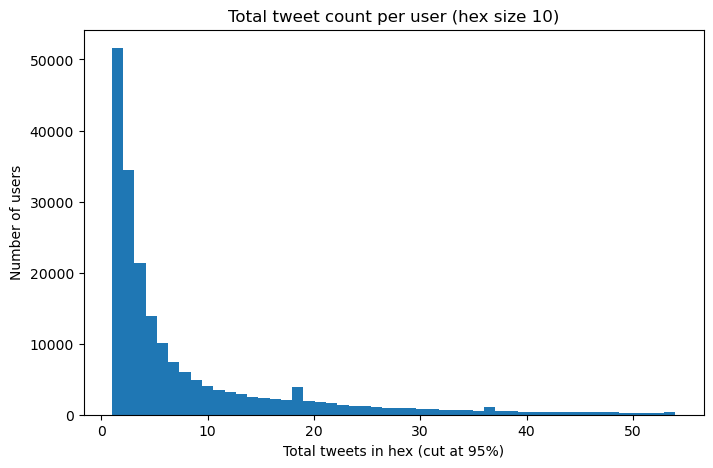

In [3]:
plt.figure(figsize=(8,5))
plt.hist(df_s10[df_s10['tweet_all_s10_cnt'] <= upper_s10]['tweet_all_s10_cnt'], bins=50)
plt.xlabel('Total tweets in hex (cut at 95%)')
plt.ylabel('Number of users')
plt.title('Total tweet count per user (hex size 10)')
plt.show()

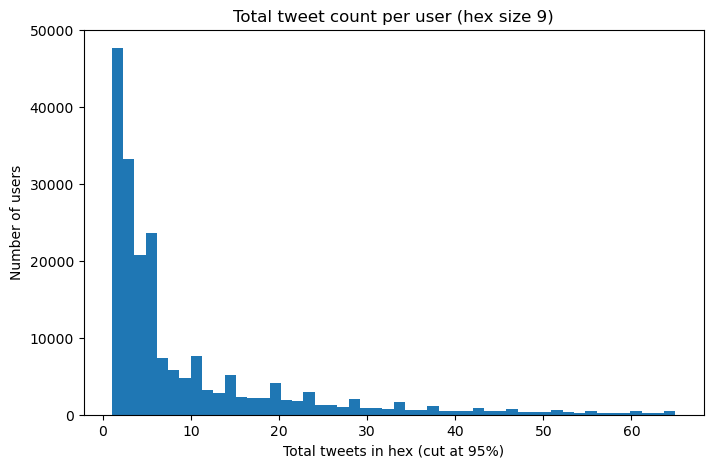

In [4]:
plt.figure(figsize=(8,5))
plt.hist(df_s9[df_s9['tweet_all_s9_cnt'] <= upper_s9]['tweet_all_s9_cnt'], bins=50)
plt.xlabel('Total tweets in hex (cut at 95%)')
plt.ylabel('Number of users')
plt.title('Total tweet count per user (hex size 9)')
plt.show()

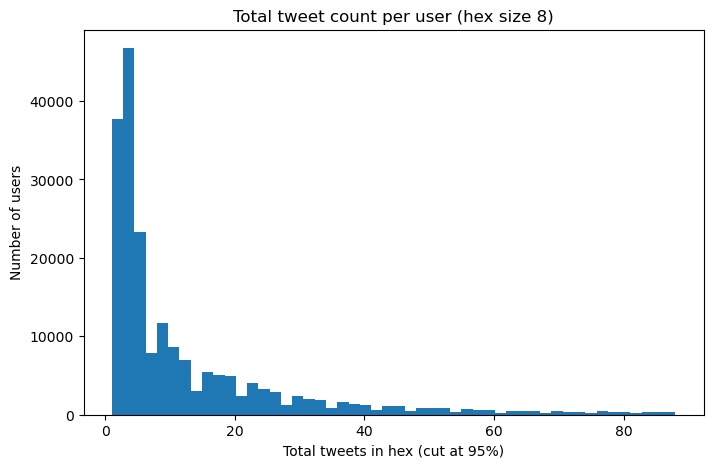

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df_s8[df_s8['tweet_all_s8_cnt'] <= upper_s8]['tweet_all_s8_cnt'], bins=50)
plt.xlabel('Total tweets in hex (cut at 95%)')
plt.ylabel('Number of users')
plt.title('Total tweet count per user (hex size 8)')
plt.show()

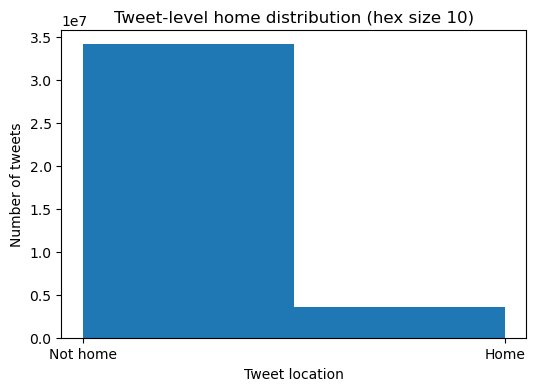

In [5]:
homeloc_10 = pd.read_sql("""
select homelocation_h3_10
from homelocation_zi
""", engine)

homeloc_10['home_flag'] = (homeloc_10['homelocation_h3_10'] == 'Y').astype(int)

plt.figure(figsize=(6,4))
plt.hist(homeloc_10['home_flag'], bins=2)
plt.xticks([0,1], ['Not home', 'Home'])
plt.xlabel('Tweet location')
plt.ylabel('Number of tweets')
plt.title('Tweet-level home distribution (hex size 10)')
plt.show()

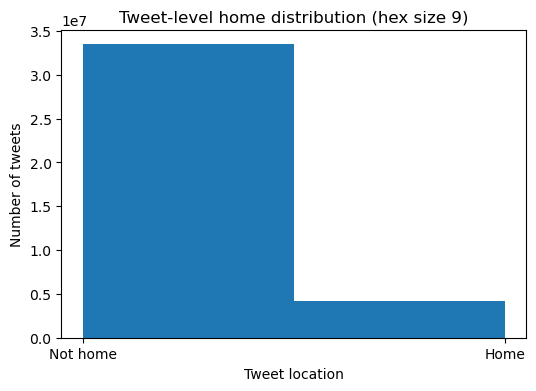

In [6]:
homeloc_9 = pd.read_sql("""
select homelocation_h3_9
from homelocation_zi
""", engine)

homeloc_9['home_flag'] = (homeloc_9['homelocation_h3_9'] == 'Y').astype(int)

plt.figure(figsize=(6,4))
plt.hist(homeloc_9['home_flag'], bins=2)
plt.xticks([0,1], ['Not home', 'Home'])
plt.xlabel('Tweet location')
plt.ylabel('Number of tweets')
plt.title('Tweet-level home distribution (hex size 9)')
plt.show()

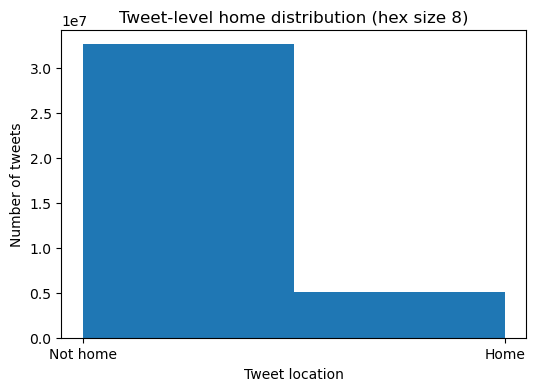

In [7]:
homeloc_8 = pd.read_sql("""
select homelocation_h3_8
from homelocation_zi
""", engine)

homeloc_8['home_flag'] = (homeloc_8['homelocation_h3_8'] == 'Y').astype(int)

plt.figure(figsize=(6,4))
plt.hist(homeloc_8['home_flag'], bins=2)
plt.xticks([0,1], ['Not home', 'Home'])
plt.xlabel('Tweet location')
plt.ylabel('Number of tweets')
plt.title('Tweet-level home distribution (hex size 8)')
plt.show()

In [8]:
pd.read_sql("""
select city, count(*) cnt
from mention_network_same_homeloc_s9_zi
group by city
order by 1
limit 10""", engine)

,city,cnt
0,amsterdam,21173
1,london,1060666
2,portland,80157


In [9]:
pd.read_sql("""
select city, count(*) cnt
from mention_network_same_homeloc_s8_zi
group by city
order by 1
limit 10""", engine)

,city,cnt
0,amsterdam,21373
1,london,1075716
2,portland,80247


In [10]:
pd.read_sql("""
select city, count(*) cnt
from reply_network_same_homeloc_s10_zi
group by city
order by 1
limit 10""", engine)

,city,cnt
0,amsterdam,24446
1,london,1371145
2,portland,84352


In [11]:
pd.read_sql("""
select city, count(*) cnt
from reply_network_same_homeloc_s9_zi
group by city
order by 1
limit 10""", engine)

,city,cnt
0,amsterdam,24592
1,london,1382768
2,portland,84388


In [ ]:
pd.read_sql("""
select city, count(*) cnt
from reply_network_same_homeloc_s8_zi
group by city
order by 1
limit 10""", engine)

,city,cnt
0,amsterdam,25059
1,london,1397190
2,portland,84467


In [3]:
pd.read_sql("""
    select city_bbox, count(distinct tweet_id) cnt from homelocation_zi group by city_bbox
""", engine)

,city_bbox,cnt
0,amsterdam,1647597
1,london,31838195
2,portland,4199557
